In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

from sklearn.feature_extraction.text import CountVectorizer

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

if HAS_SEABORN:
    sns.set_theme(style='whitegrid')

print('Seaborn available:', HAS_SEABORN)


Seaborn available: True


In [2]:
DATA_PATH = Path('email_dataset_100k.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print('Dataset loaded from:', DATA_PATH.resolve())
print('Shape:', df.shape)


Dataset loaded from: C:\Users\SREEVIBU\Downloads\spam\email_dataset_100k.csv
Shape: (100000, 30)


In [3]:
df.head(3)


,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,hour_of_day,message_id,in_reply_to,num_received_headers,received_origin_ip,spf_result,dkim_result,dmarc_result,has_attachments,attachment_types,has_html,num_urls,num_emails_in_body,num_phone_numbers,contains_tracking_token,x_spam_score,user_agent,list_unsubscribe,language,label
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe received invoice 765713. It will be processed by Accounts Payable.\n\...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It will be processed by Accounts Payable.\n\nBest,\nWendy",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,16,<oazqpryu589441@adatum.net>,<bfkcgor40826@hr-mail.net>,7,155.60.143.1,fail,fail,none,True,report_314379.pdf;agenda_095693.ics;confirm_084392.pdf;confirm_882079.ics,False,0,0,1,False,0.00,Microsoft Outlook,NaN,en,0
1,"Subject: WINNER! Claim your reward\nDear user,\n\nYour parcel has been flagged. To restore access, click the link be...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To restore access, click the link below:\nhttps://update.info/billing/94...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,1,<pqtmebqsmg7134@bpzwgl.app>,NaN,5,84.17.122.15,pass,fail,none,False,NaN,False,1,0,1,False,4.82,Mutt,NaN,en,1
2,"Subject: Follow-up: onboarding tasks\nHi Zack,\n\nHere are the notes from our meeting. Please review the attached do...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meeting. Please review the attached document and add comments.\n\nThanks,\nF...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,16,<gfvgdcfr699306@cohosu.org>,NaN,4,201.192.196.145,pass,pass,pass,False,NaN,False,0,0,0,False,0.00,Apple Mail,NaN,de,0


In [4]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True)
}).sort_values(by='null_pct', ascending=False)

summary


,dtype,non_null_count,null_count,null_pct,n_unique
in_reply_to,object,14973,85027,85.03,14973
cc_addresses,object,19902,80098,80.10,19092
list_unsubscribe,object,19909,80091,80.09,19909
attachment_types,object,20142,79858,79.86,20139
reply_to,object,29918,70082,70.08,15374
body_html,object,42403,57597,57.60,38514
from_domain,object,100000,0,0.00,18
from_address,object,100000,0,0.00,42740
body_plain,object,100000,0,0.00,80518
to_addresses,object,100000,0,0.00,42591


In [5]:
print('Duplicate full rows:', df.duplicated().sum())
if 'message_id' in df.columns:
    print('Duplicate message_id values:', df['message_id'].duplicated().sum())


Duplicate full rows: 0
Duplicate message_id values: 0


,count,percent
label,,
0,50000,50.0
1,50000,50.0


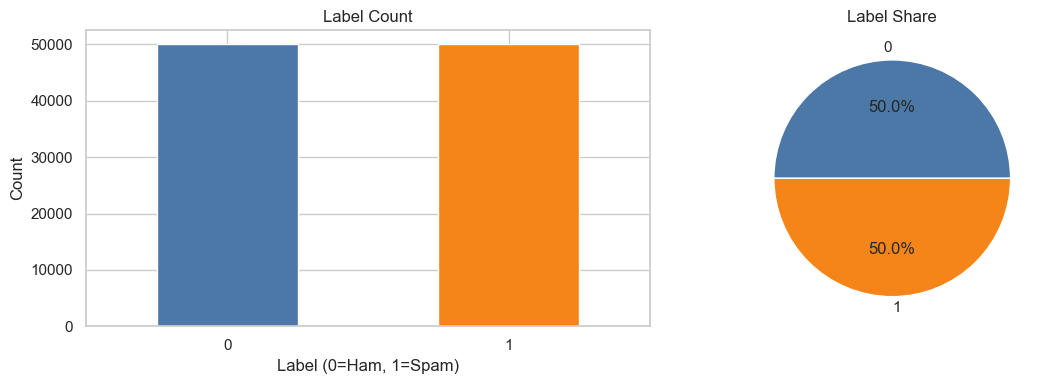

In [6]:
if 'label' not in df.columns:
    raise ValueError('Expected `label` column was not found.')

label_counts = df['label'].value_counts(dropna=False).sort_index()
label_pct = (df['label'].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)

display(pd.DataFrame({'count': label_counts, 'percent': label_pct}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

label_counts.plot(kind='bar', ax=ax[0], color=['#4c78a8', '#f58518'])
ax[0].set_title('Label Count')
ax[0].set_xlabel('Label (0=Ham, 1=Spam)')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=0)

label_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax[1], colors=['#4c78a8', '#f58518'])
ax[1].set_ylabel('')
ax[1].set_title('Label Share')

plt.tight_layout()
plt.show()


In [7]:
text_cols = [col for col in ['raw_text', 'subject', 'body_plain'] if col in df.columns]

for col in text_cols:
    df[f'{col}_len'] = df[col].fillna('').astype(str).str.len()

len_cols = [f'{col}_len' for col in text_cols]
df[len_cols + ['label']].describe().T


,count,mean,std,min,25%,50%,75%,max
raw_text_len,100000.0,162.96942,32.966622,87.0,141.0,155.0,184.0,277.0
subject_len,100000.0,29.48243,6.326352,15.0,25.0,29.0,34.0,52.0
body_plain_len,100000.0,123.48699,29.943102,62.0,105.0,115.0,140.0,220.0
label,100000.0,0.50000,0.500003,0.0,0.0,0.5,1.0,1.0


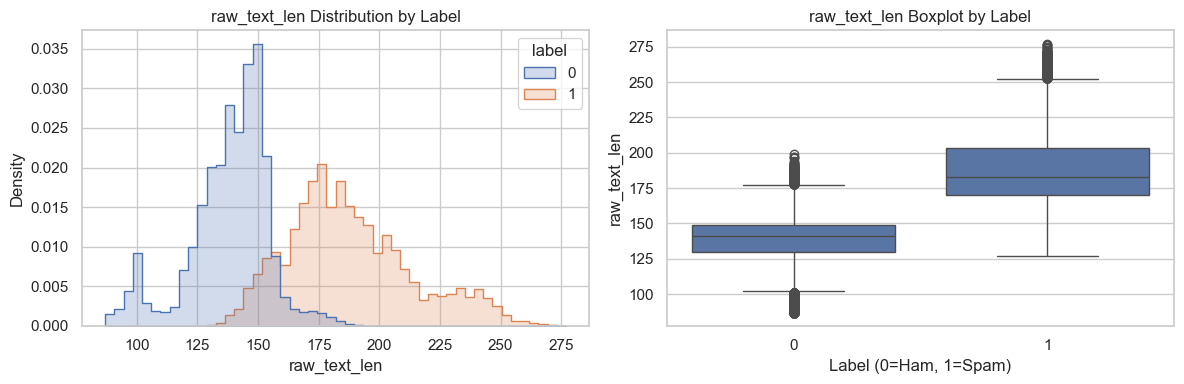

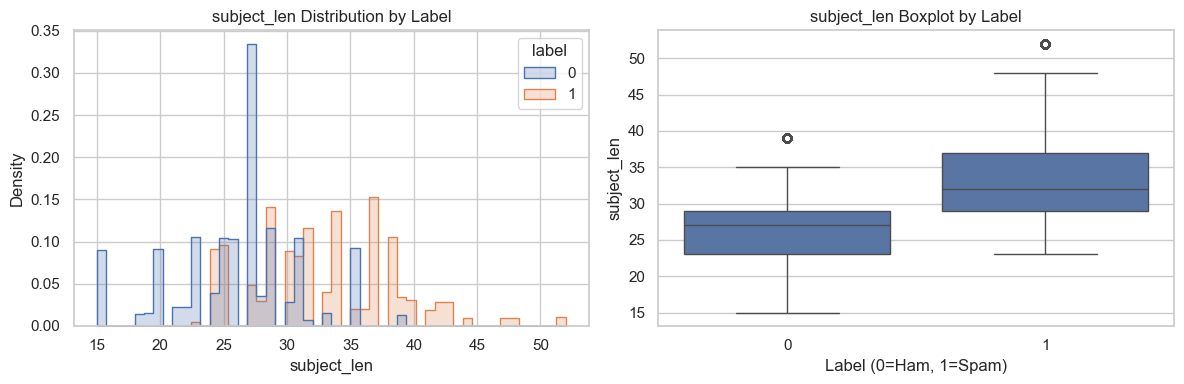

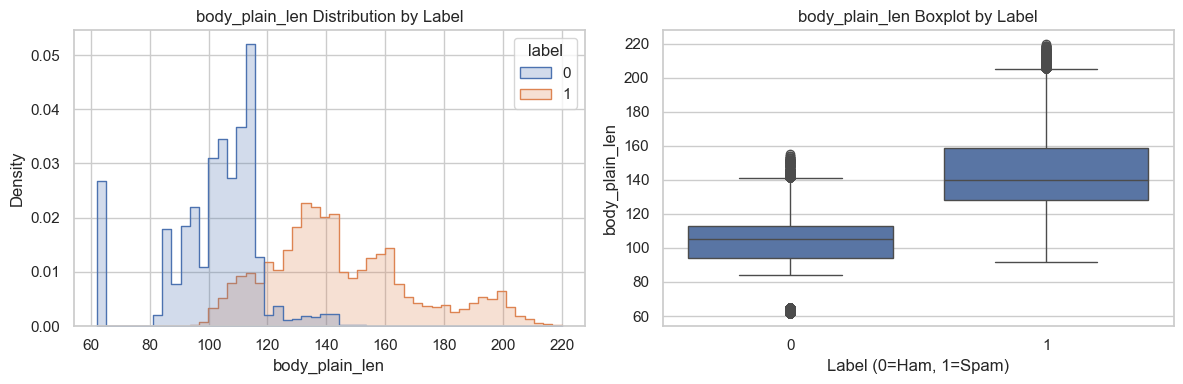

In [8]:
for col in [f'{c}_len' for c in text_cols]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    if HAS_SEABORN:
        sns.histplot(data=df, x=col, hue='label', bins=50, element='step', stat='density', common_norm=False, ax=ax[0])
        sns.boxplot(data=df, x='label', y=col, ax=ax[1])
    else:
        for lbl, color in [(0, '#4c78a8'), (1, '#f58518')]:
            subset = df.loc[df['label'] == lbl, col].dropna()
            ax[0].hist(subset, bins=50, alpha=0.4, label=f'label={lbl}', color=color, density=True)
        ax[0].legend()
        ax[0].set_ylabel('Density')
        grouped = [df.loc[df['label'] == lbl, col].dropna() for lbl in sorted(df['label'].dropna().unique())]
        ax[1].boxplot(grouped, labels=sorted(df['label'].dropna().unique()))

    ax[0].set_title(f'{col} Distribution by Label')
    ax[1].set_title(f'{col} Boxplot by Label')
    ax[1].set_xlabel('Label (0=Ham, 1=Spam)')
    plt.tight_layout()
    plt.show()


In [9]:
candidate_numeric = [
    'hour_of_day', 'num_received_headers', 'has_attachments', 'has_html',
    'num_urls', 'num_emails_in_body', 'num_phone_numbers',
    'contains_tracking_token', 'x_spam_score', 'label'
]

numeric_cols = [c for c in candidate_numeric if c in df.columns]
num_df = df[numeric_cols].copy()

for c in num_df.columns:
    if num_df[c].dtype == object:
        num_df[c] = pd.to_numeric(num_df[c], errors='coerce')

num_df.describe().T


,count,mean,std,min,25%,50%,75%,max
hour_of_day,100000.0,11.487060,6.911186,0.0,6.0,11.0,17.0,23.0
num_received_headers,100000.0,4.507110,1.501783,2.0,3.0,5.0,6.0,7.0
num_urls,100000.0,0.799700,0.871543,0.0,0.0,0.5,2.0,2.0
num_emails_in_body,100000.0,0.041960,0.200499,0.0,0.0,0.0,0.0,1.0
num_phone_numbers,100000.0,0.634160,0.561573,0.0,0.0,1.0,1.0,2.0
x_spam_score,100000.0,4.000137,4.319804,0.0,0.0,2.0,8.0,12.0
label,100000.0,0.500000,0.500003,0.0,0.0,0.5,1.0,1.0


In [10]:
mean_by_label = num_df.groupby(df['label']).mean(numeric_only=True).T
mean_by_label.columns = [f'label_{c}_mean' for c in mean_by_label.columns]
mean_by_label.sort_index()


,label_0_mean,label_1_mean
contains_tracking_token,0.04994,0.603600
has_attachments,0.15132,0.251520
has_html,0.24866,0.599400
hour_of_day,11.50704,11.467080
label,0.00000,1.000000
num_emails_in_body,0.00000,0.083920
num_phone_numbers,0.18496,1.083360
num_received_headers,5.00954,4.004680
num_urls,0.00000,1.599400
x_spam_score,0.00000,8.000274


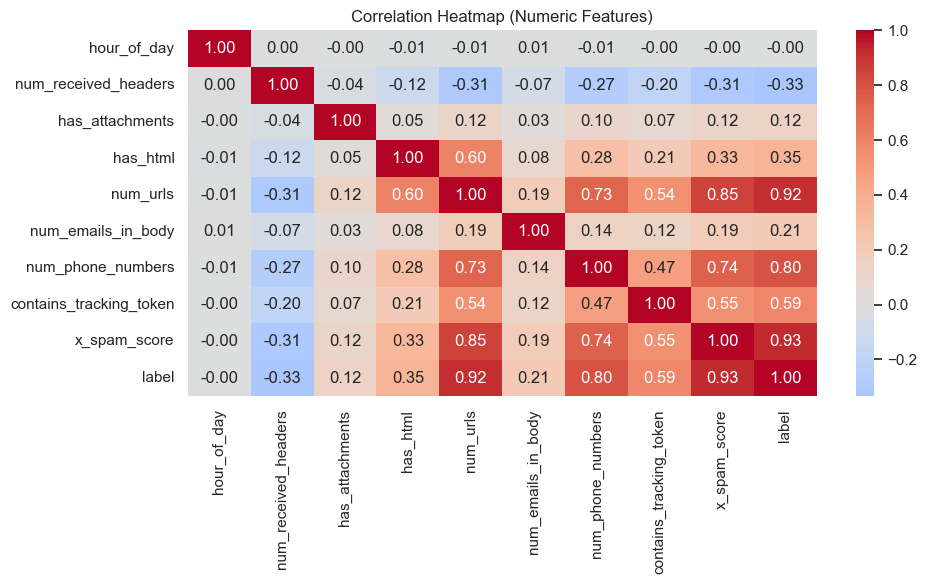

In [11]:
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
if HAS_SEABORN:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
else:
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


In [12]:
for col in ['spf_result', 'dkim_result', 'dmarc_result', 'language']:
    if col in df.columns:
        print(f'\n=== {col} vs label ===')
        ct = pd.crosstab(df[col].fillna('missing'), df['label'], normalize='columns')
        display((ct * 100).round(2))



=== spf_result vs label ===


label,0,1
spf_result,,
fail,9.88,50.04
neutral,9.81,30.20
pass,80.31,19.76



=== dkim_result vs label ===


label,0,1
dkim_result,,
fail,9.77,49.72
neutral,9.94,30.15
pass,80.29,20.13



=== dmarc_result vs label ===


label,0,1
dmarc_result,,
fail,10.29,39.70
none,19.98,40.22
pass,69.73,20.07



=== language vs label ===


label,0,1
language,,
de,9.73,10.14
en,60.12,59.94
es,10.04,9.92
fr,9.95,10.13
it,10.15,9.87


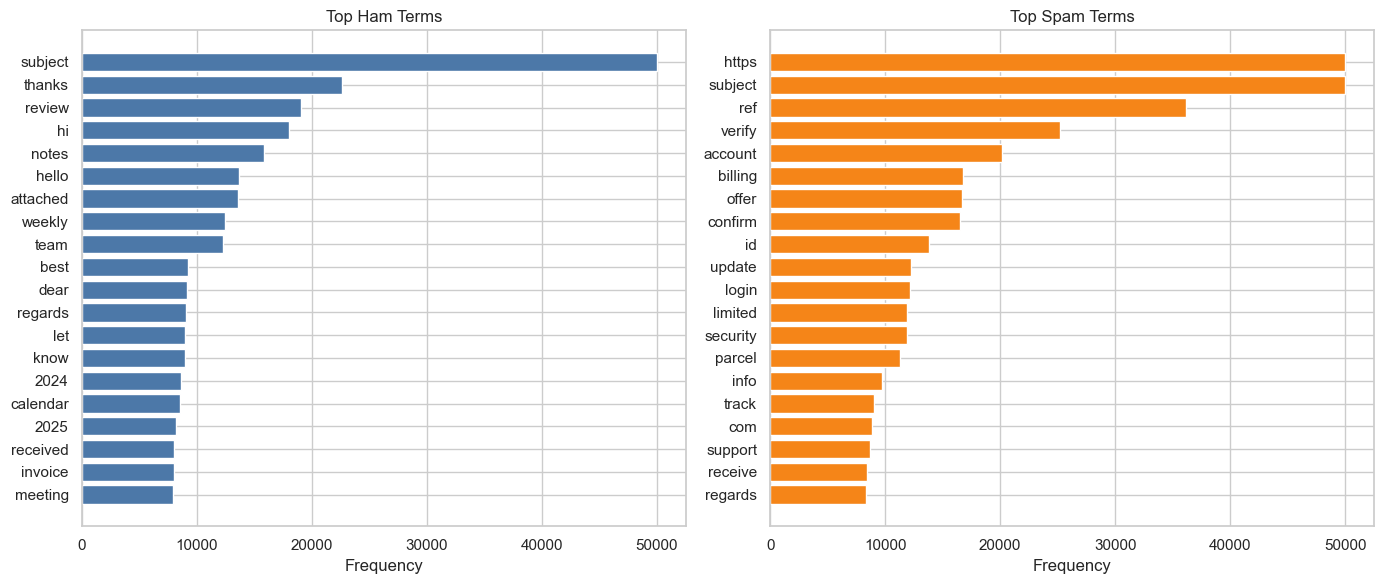

,term,frequency
0,subject,50000
1,thanks,22601
2,review,19033
3,hi,18038
4,notes,15836
5,hello,13637
6,attached,13584
7,weekly,12445
8,team,12296
9,best,9248


,term,frequency
0,https,50000
1,subject,50000
2,ref,36142
3,verify,25179
4,account,20175
5,billing,16753
6,offer,16640
7,confirm,16457
8,id,13782
9,update,12253


In [13]:
if 'raw_text' in df.columns:
    top_n = 20

    def top_terms_for_label(label_value, n=top_n):
        subset = df.loc[df['label'] == label_value, 'raw_text'].fillna('').astype(str)
        vec = CountVectorizer(stop_words='english', max_features=5000)
        x = vec.fit_transform(subset)
        freqs = np.asarray(x.sum(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        top_idx = freqs.argsort()[-n:][::-1]
        return pd.DataFrame({'term': terms[top_idx], 'frequency': freqs[top_idx]})

    ham_terms = top_terms_for_label(0, top_n)
    spam_terms = top_terms_for_label(1, top_n)

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].barh(ham_terms['term'][::-1], ham_terms['frequency'][::-1], color='#4c78a8')
ax[0].set_title('Top Ham Terms')

ax[1].barh(spam_terms['term'][::-1], spam_terms['frequency'][::-1], color='#f58518')
ax[1].set_title('Top Spam Terms')

for a in ax:
    a.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

display(ham_terms.head(10))
display(spam_terms.head(10))


## EDA Summary Template

Fill this after running all cells:
1. Class balance: ...
2. Missing-data concerns: ...
3. Most predictive text/metadata signals observed: ...
4. Features to keep for baseline model: ...
5. Next experiments (feature engineering/modeling): ...
